# Model Interpretability with SHAP

High predictive performance is not sufficient in fraud detection. Models must 
also be interpretable to:
- Understand key risk drivers
- Support audit and regulatory review
- Build stakeholder trust
- Diagnose model behavior

This notebook uses SHAP (SHapley Additive exPlanations) to interpret the 
predictions of the final model — **XGBoost, threshold 0.82** — selected based 
on dollar-weighted cost-sensitive optimisation in Notebook 5. Random Forest is 
retained as a secondary comparison to check whether both model families rely 
on similar risk drivers.

In [26]:
!pip install shap


### 1. Imports, Paths & Load Test Set

In [27]:
# 1. Imports
import os
#import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

### 2. Paths, directories

In [28]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
PLOTS_DIR = os.path.join(PROJECT_ROOT, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

### 3. Load Test Data

- Load the held-out test dataset and the tuned model objects from Notebook 4 (SMOTE-in-CV corrected version)
- Test data is used here purely for interpretation — SHAP explains an already-finalized model and threshold, and does not influence any decision, so this does not conflict with the test set's one-time use for final reporting in Notebook 5

SHAP explanations are computed on a sampled subset (1,000 transactions) for computational efficiency.

In [29]:
# 3. Load preprocessed test set
X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test.csv"))
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv")).iloc[:, 0]

### 4. Load Tuned Models (XGBoost + Random Forest)

- **XGBoost** is used as the primary interpretability reference, as it is the model selected for deployment in Notebook 5
- Random Forest is retained as a secondary comparisIon, to check whether both model families rely on similar risk drivers
- Models are loaded from `tuned_models_latest.pkl`, reflecting the SMOTE-in-CV corrected versions from Notebook 4

In [30]:
# 4. Load tuned models (SMOTE-in-CV corrected version from Notebook 4)
with open(os.path.join(MODELS_DIR, "tuned_models_latest.pkl"), "rb") as f:
    tuned_models = pickle.load(f)

# XGBoost is the primary model (selected in Notebook 5 based on cost)
xgb_model = tuned_models["XGBoost"]
rf_model = tuned_models["RandomForest"]  # secondary, for comparison

### 5. Compute SHAP Values (XGBoost)

SHAP's `TreeExplainer`, optimized for tree-based models, is used to compute feature contributions for XGBoost, the final selected model.

- 1,000 observations are sampled from the test set for computational efficiency
- The fitted classifier is extracted from inside the SMOTE pipeline — `TreeExplainer` requires the underlying tree model directly, not the pipeline wrapper. SMOTE only affects training and plays no role in explaining already-made predictions.
- SHAP values are extracted for the fraud class

**Note on SHAP output shape:** Random Forest (scikit-learn) and XGBoost's `TreeExplainer` return SHAP values in different array shapes for binary classification — Random Forest returns one slice per class (3D array), requiring `[:, :, 1]` to select the fraud class, while XGBoost returns a single 2D array directly, requiring no class-index slicing.

In [31]:
# 5. Compute SHAP values for XGBoost (primary model)
X_sample = X_test.sample(1000, random_state=42)

# Extract the actual fitted classifier from inside the pipeline —
# SHAP's TreeExplainer needs the tree model directly, not the pipeline wrapper.
# SMOTE (the other pipeline step) only affects training, not prediction, so
# it plays no role in explaining already-made predictions.
xgb_classifier = xgb_model.named_steps["model"]

explainer_xgb = shap.TreeExplainer(xgb_classifier)
shap_values_xgb = explainer_xgb.shap_values(X_sample)

shap_values_xgb_fraud = shap_values_xgb

### 6. Global feature importance

SHAP summary plots visualize global feature importance for the final XGBoost model:

1. Bar Plot  
   - Shows mean absolute SHAP value indicating overall feature importance

2. Beeswarm Plot  
   - distribution of feature effects, showing both direction and magnitude of influence

These plots explain which variables drive fraud risk globally. 
Features with larger mean absolute SHAP values have a stronger influence on fraud predictions.

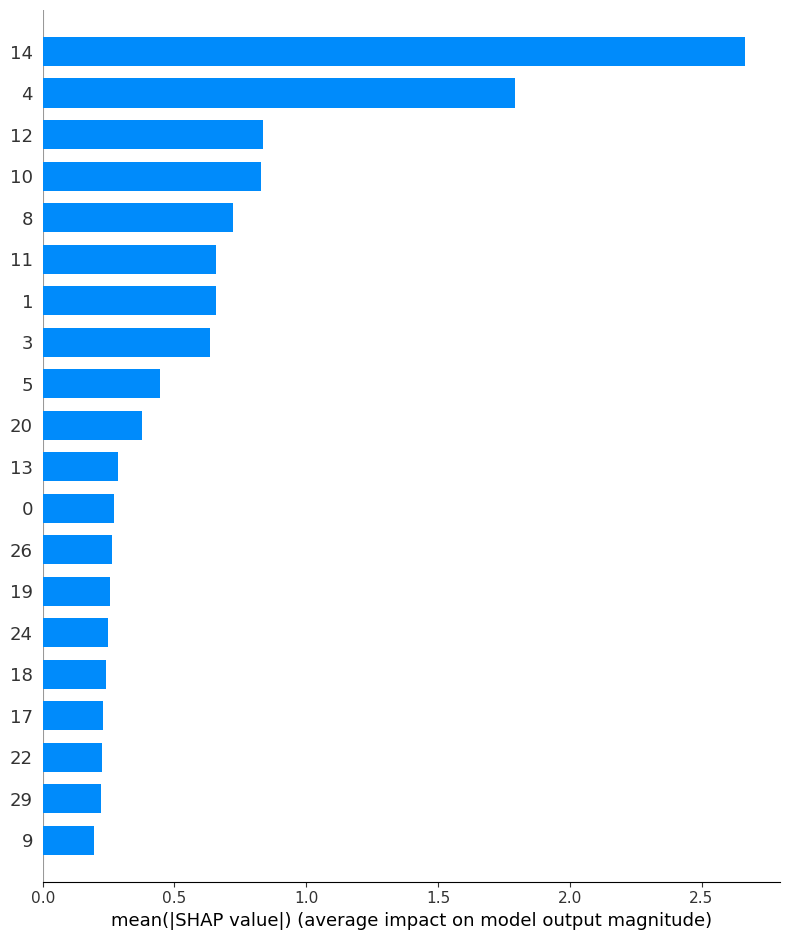

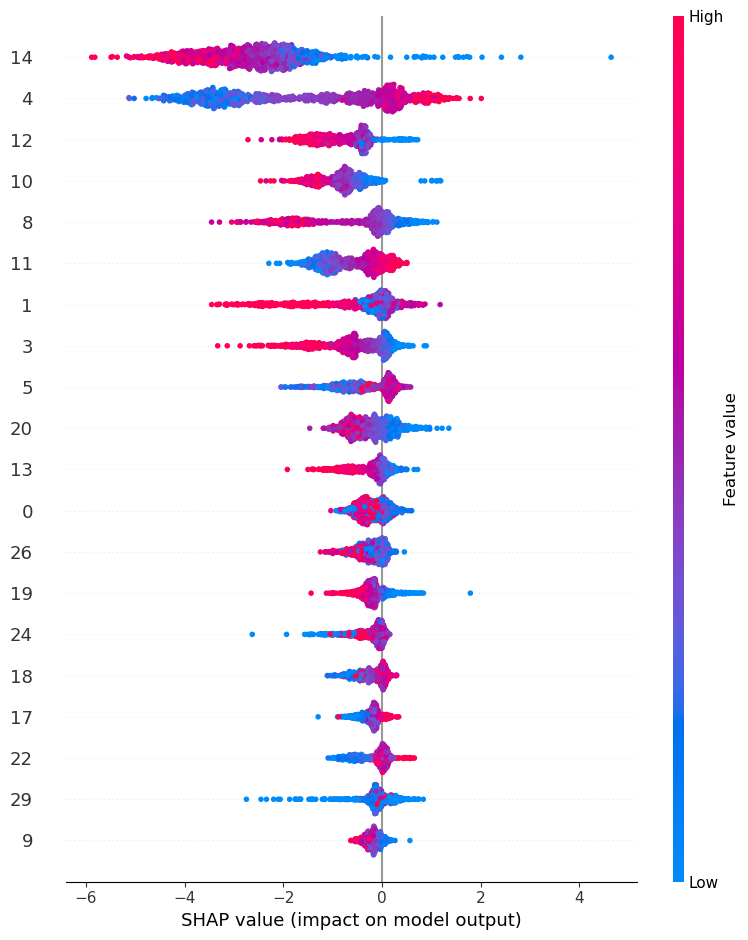

In [32]:
shap.summary_plot(
    shap_values_xgb_fraud,
    X_sample,
    plot_type="bar",
    show=False
)
plt.savefig(os.path.join(PLOTS_DIR, "shap_xgboost_bar.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

shap.summary_plot(
    shap_values_xgb_fraud,
    X_sample,
    show=False
)
plt.savefig(os.path.join(PLOTS_DIR, "shap_xgboost_beeswarm.png"), dpi=300, bbox_inches="tight")
plt.show()

In [33]:
#import numpy as np
#import pandas as pd

mean_abs_shap = np.abs(shap_values_xgb_fraud).mean(axis=0)
feature_importance = pd.DataFrame({
    "Feature": X_sample.columns,
    "Mean |SHAP value|": mean_abs_shap
}).sort_values("Mean |SHAP value|", ascending=False)

print(feature_importance.head(10))

   Feature  Mean |SHAP value|
14      14           2.664522
4        4           1.791275
12      12           0.836868
10      10           0.827000
8        8           0.721559
11      11           0.656429
1        1           0.656141
3        3           0.636452
5        5           0.446499
20      20           0.377702


### 7. Local Explanation (Illustrative)

A SHAP force plot for a single test instance illustrates how individual feature 
contributions combine to produce XGBoost's prediction for that transaction.

**Interpretation note:**
- Positive SHAP values push the prediction toward fraud
- Negative SHAP values push the prediction toward legitimate
- The expected value represents the model's baseline fraud probability across 
  the sample

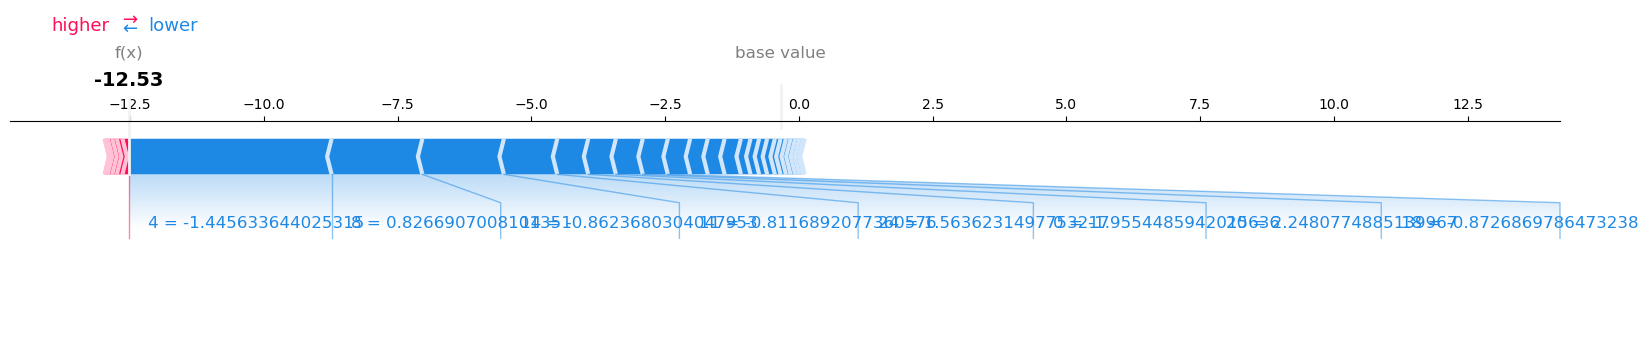

In [34]:
# 7. SHAP force plot for a fraud-class prediction (XGBoost)
row = 0

shap.initjs()

shap.force_plot(
    explainer_xgb.expected_value,          # single value for XGBoost (no class indexing)
    shap_values_xgb_fraud[row, :],
    X_sample.iloc[row, :],
    matplotlib=True
)

### 8. Secondary Comparison (Random Forest)

SHAP values are also computed for Random Forest, to:
- Compare feature importance consistency between model families
- Validate whether both models rely on similar risk drivers
- Detect model-specific biases or instability

Consistent importance rankings between XGBoost and Random Forest would increase confidence that identified risk drivers reflect genuine fraud patterns, rather than artifacts specific to one algorithm. Random Forest is shown for this comparison only — it is not the deployed model.

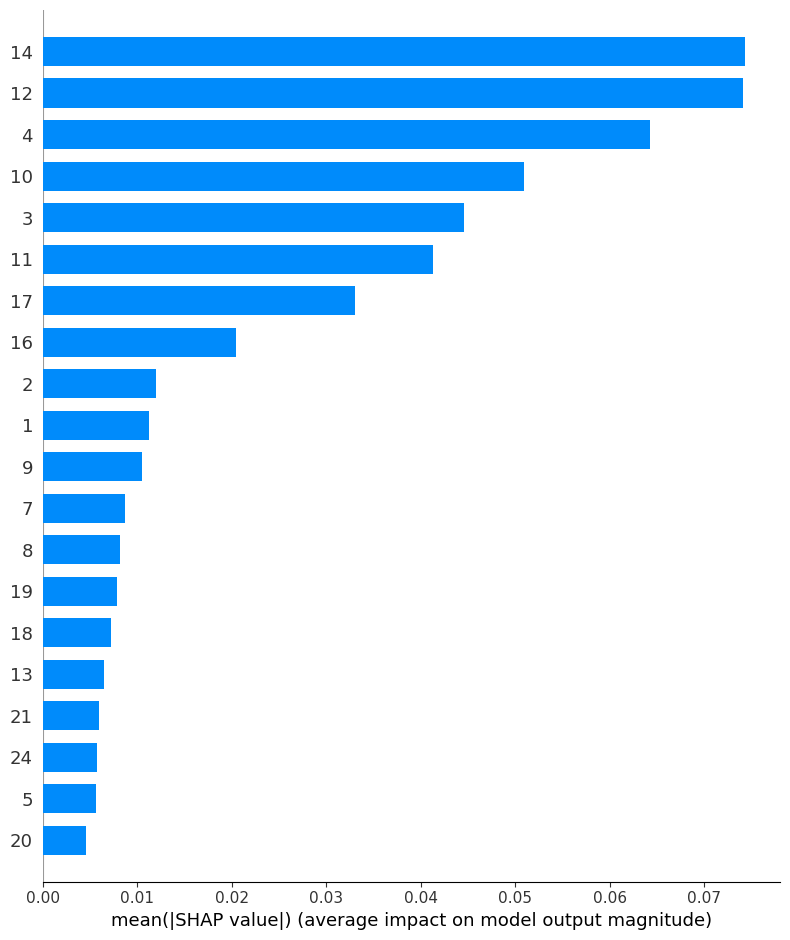

<Figure size 640x480 with 0 Axes>

In [35]:
# 8. Optional SHAP comparison with Random Forest
rf_classifier = rf_model.named_steps["model"]

explainer_rf = shap.TreeExplainer(rf_classifier)
shap_values_rf = explainer_rf.shap_values(X_sample)
shap_values_rf_fraud = shap_values_rf[:, :, 1]  # RF needs class-1 slicing

shap.summary_plot(shap_values_rf_fraud,X_sample,plot_type="bar",show=True)
plt.savefig(os.path.join(PLOTS_DIR, "shap_randomforest_bar.png"), dpi=300, bbox_inches="tight")
plt.show()

XGBoost exhibits a similar feature importance pattern, suggesting consistency in the underlying fraud signals learned by both models.

However, Random Forest remains the primary model due to superior cost-sensitive performance.


### Interpretability Takeaways

Global SHAP analysis reveals a concentrated importance structure for the final 
XGBoost model:
- **V14 is the dominant predictor** (mean |SHAP| ≈ 2.66), contributing roughly 1.5x more than the next-ranked feature
- **V4** forms a clear second tier on its own (≈1.79)
- A secondary cluster of moderate contributors follows — **V12, V10, V8, V11, V1, V3** (roughly 0.64–0.84 each)
- The remaining features contribute comparatively little, forming a long tail

This hierarchy indicates the model relies on a small number of strong predictors rather than diffuse aggregation across many weak variables, which makes the model's behavior easier to understand, document, and monitor over time.

**Cross-model consistency:** Random Forest's top features — V14, V12, V4, V10, V3, V11 — substantially overlap with XGBoost's top group, despite the two models using structurally different algorithms (sequential boosting vs. independent tree ensembles). Six of the top features are shared between both models' leading groups. This consistency increases confidence that these signals reflect genuine underlying fraud patterns in the data, rather than artifacts specific to one algorithm's inductive bias.

One notable difference: Random Forest ranks **V12 essentially equal to V14**, while XGBoost places V14 clearly ahead of everything else, including V4. This suggests XGBoost's sequential, error-correcting boosting process converges on a slightly more concentrated reliance on a single top feature, whereas Random Forest's independent trees distribute importance somewhat more evenly across its top two predictors. This is a reasonable and expected difference in how the two algorithms weigh features, not a sign of instability.

Given XGBoost's selection as the final deployment model (Notebook 5), **V14 and V4 should be prioritised for drift monitoring** — if their distributions shift meaningfully in production data over time, this would be an early warning sign that the model's core decision logic may no longer reflect current fraud patterns, warranting retraining.

### 9. Error Analysis

The confusion matrix tells us *how many* errors the model makes, but not *what kind* of transactions it gets wrong. This section examines the actual missed frauds (false negatives) and false alarms (false positives) at the deployed threshold (0.82), comparing their transaction amounts against correctly classified cases, to understand whether errors follow a discernible pattern.

False Negatives (missed fraud): 18
False Positives (flagged legitimate): 10

--- Transaction amount: Missed fraud (FN) vs Caught fraud (TP) ---
Missed (FN):
 count      18.000000
mean      212.969444
std       450.815771
min         1.000000
25%         1.197500
50%         4.140000
75%       159.247500
max      1809.680000
Name: Amount, dtype: float64

Caught (TP):
 count     80.000000
mean      85.143500
std      141.566587
min        0.000000
25%        1.000000
50%       11.505000
75%       99.990000
max      802.520000
Name: Amount, dtype: float64

--- Transaction amount: False alarms (FP) vs Correctly passed (TN, sample) ---
False alarms (FP):
 count    10.000000
mean     34.532000
std      35.191707
min       0.000000
25%       1.000000
50%      31.005000
75%      56.377500
max      89.990000
Name: Amount, dtype: float64

Correctly passed (TN, random sample of 1000):
 count    1000.000000
mean      101.325750
std       265.250973
min         0.000000
25%         5.965000
50%    

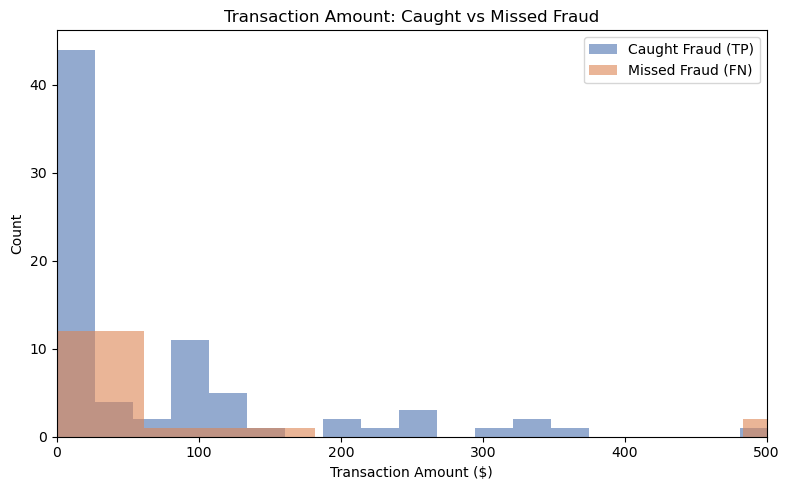

In [36]:
# --- Section 9: Error Analysis ---
# Load original amounts and generate full-test-set predictions at the deployed threshold
FINAL_THRESHOLD = 0.82

amount_test = pd.read_csv(os.path.join(DATA_DIR, "amount_test.csv")).iloc[:, 0]

xgb_full_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_full_preds = (xgb_full_probs >= FINAL_THRESHOLD).astype(int)

fn_mask = (y_test == 1) & (xgb_full_preds == 0)   # missed fraud
fp_mask = (y_test == 0) & (xgb_full_preds == 1)   # false alarms
tp_mask = (y_test == 1) & (xgb_full_preds == 1)   # correctly caught fraud
tn_mask = (y_test == 0) & (xgb_full_preds == 0)   # correctly passed legitimate

print(f"False Negatives (missed fraud): {fn_mask.sum()}")
print(f"False Positives (flagged legitimate): {fp_mask.sum()}")

print("\n--- Transaction amount: Missed fraud (FN) vs Caught fraud (TP) ---")
print("Missed (FN):\n", amount_test[fn_mask].describe())
print("\nCaught (TP):\n", amount_test[tp_mask].describe())

print("\n--- Transaction amount: False alarms (FP) vs Correctly passed (TN, sample) ---")
print("False alarms (FP):\n", amount_test[fp_mask].describe())
print("\nCorrectly passed (TN, random sample of 1000):\n", amount_test[tn_mask].sample(1000, random_state=42).describe())

plt.figure(figsize=(8, 5))
plt.hist(amount_test[tp_mask], bins=30, alpha=0.6, label="Caught Fraud (TP)", color="#4C72B0")
plt.hist(amount_test[fn_mask], bins=30, alpha=0.6, label="Missed Fraud (FN)", color="#DD8452")
plt.xlabel("Transaction Amount ($)")
plt.ylabel("Count")
plt.title("Transaction Amount: Caught vs Missed Fraud")
plt.xlim(0, 500)  # zoom in, since most fraud is low-value
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "error_analysis_amount_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

### 10. Missed Fraud by Hour of Day

Extending the Error Analysis above, this checks whether missed frauds (false negatives) cluster at particular hours of the day, using the same hourly segmentation from the original EDA (Notebook 1).

In [37]:
# --- 10. Missed Fraud by Hour of Day ---
time_test = pd.read_csv(os.path.join(DATA_DIR, "time_test.csv")).iloc[:, 0]

hour_test = (time_test // 3600) % 24

error_by_hour = pd.DataFrame({
    "Hour": hour_test,
    "Actual_Fraud": y_test.values,
    "Missed_Fraud": fn_mask.values.astype(int)
})

fraud_by_hour = error_by_hour.groupby("Hour")["Actual_Fraud"].sum()
missed_by_hour = error_by_hour.groupby("Hour")["Missed_Fraud"].sum()

hour_summary = pd.DataFrame({
    "Total_Fraud": fraud_by_hour,
    "Missed_Fraud": missed_by_hour,
    "Miss_Rate_%": (missed_by_hour / fraud_by_hour * 100).round(1)
}).fillna(0)

hour_summary

,Total_Fraud,Missed_Fraud,Miss_Rate_%
Hour,,,
0.0,2,1,50.0
1.0,4,1,25.0
2.0,9,2,22.2
3.0,4,1,25.0
4.0,3,2,66.7
5.0,1,0,0.0
6.0,3,2,66.7
7.0,7,0,0.0
8.0,1,0,0.0


### Observations — Missed Fraud by Hour

Miss rates vary widely across hours (0% to 100%), but this must be interpreted cautiously: most hours contain only 1–4 total fraud cases in the test set, so percentages are highly sensitive to individual cases and should not be read as statistically reliable patterns. For example, the 100% miss rate at hour 21 reflects a single missed case out of one total fraud transaction that hour.

With that caveat, hours 4 and 6 show a higher proportion of missed fraud (2 of 3 cases each) worth noting directionally, but a much larger sample would be needed to confirm whether this reflects a genuine time-based model weakness or simply small-sample noise. This is flagged as a candidate for further investigation with more data, rather than a confirmed finding.

### 11. SHAP Explanation: Highest-Value Missed Fraud

Rather than examining a random missed fraud, this section explains the model's reasoning for the single highest-value missed fraud in the test set — the most financially costly error the model made. Understanding why the model was confident this transaction was legitimate is more actionable than examining a low-value, low-impact miss.

Highest-value missed fraud: $1809.68


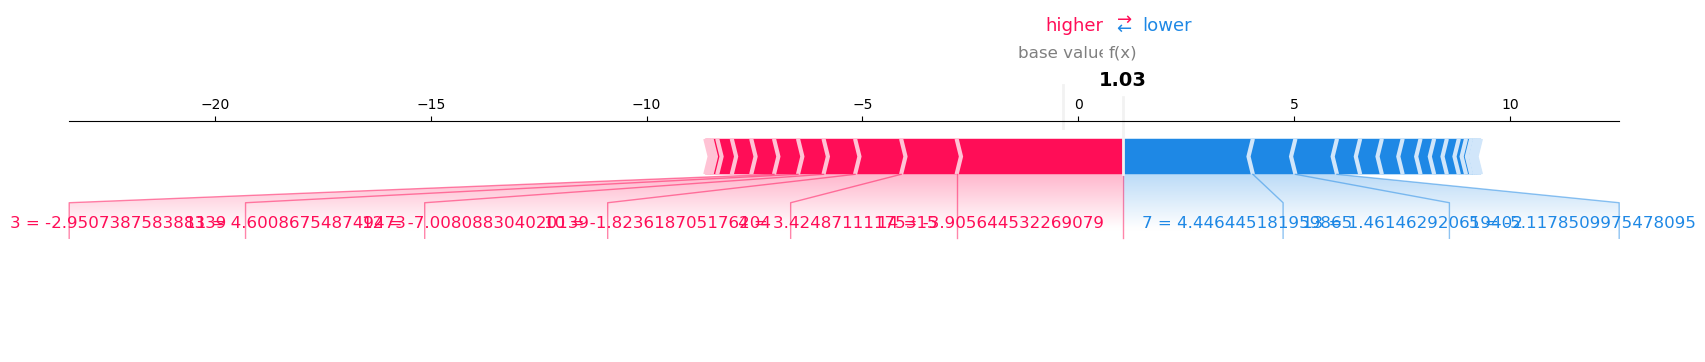

In [38]:
#11. SHAP explanation for the highest-value missed fraud (most costly error)
fn_indices = X_test[fn_mask].index
highest_value_fn_idx = amount_test[fn_mask].idxmax()

print(f"Highest-value missed fraud: ${amount_test.loc[highest_value_fn_idx]:.2f}")

# Compute SHAP values for this specific transaction
row_data = X_test.loc[[highest_value_fn_idx]]
shap_val_single = explainer_xgb.shap_values(row_data)

shap.force_plot(
    explainer_xgb.expected_value,
    shap_val_single[0, :],
    row_data.iloc[0, :],
    matplotlib=True
)

In [39]:
import pandas as pd
# Simple, readable breakdown of feature contributions for this one transaction
feature_contributions = pd.DataFrame({
    "Feature": row_data.columns,
    "Feature_Value": row_data.iloc[0].values,
    "SHAP_Value": shap_val_single[0, :]
}).sort_values("SHAP_Value", ascending=False)

print("=== Features pushing toward FRAUD (positive SHAP value) ===")
print(feature_contributions[feature_contributions["SHAP_Value"] > 0].head(10))

print("\n=== Features pushing toward LEGITIMATE (negative SHAP value) ===")
print(feature_contributions[feature_contributions["SHAP_Value"] < 0].sort_values("SHAP_Value").head(10))

=== Features pushing toward FRAUD (positive SHAP value) ===
   Feature  Feature_Value  SHAP_Value
14      14      -3.905645    3.850475
4        4       3.424871    1.285820
10      10      -1.823619    1.066738
12      12      -7.008088    0.730503
11      11       4.600868    0.591724
3        3      -2.950739    0.556158
17      17      -6.085231    0.527358
20      20      -4.026919    0.450858
8        8      -1.618128    0.336896
16      16      -2.301641    0.131117

=== Features pushing toward LEGITIMATE (negative SHAP value) ===
   Feature  Feature_Value  SHAP_Value
7        7       4.446445   -3.013646
13      13       1.461463   -0.986015
5        5      -5.117851   -0.963303
27      27       4.981482   -0.536644
23      23      -3.497211   -0.502509
0        0      -1.807890   -0.481853
19      19       2.047867   -0.414096
28      28      -2.755133   -0.315213
21      21      -1.432136   -0.294588
1        1      -1.786143   -0.277288


### Case Study: The Highest-Value Missed Fraud ($1,809.68)

SHAP analysis of this specific transaction reveals a genuinely close call, not a clear model failure. Several features pushed strongly toward a fraud prediction — most notably **V14** (the model's single most important feature overall), along with V4, V10, and V12. However, these were counteracted by an even stronger pull toward "legitimate" from **V7**, reinforced by smaller contributions from V13, V5, and V27.

The net effect was a narrow tip toward "legitimate," resulting in a missed detection. This illustrates an important nuance: the model did not fail to recognize fraud-like signals in this transaction — it recognized several, but they were outweighed by competing signals that resembled normal behavior. This is characteristic of genuinely ambiguous fraud cases, rather than a systemic model weakness, and reinforces that even a well-performing model will have some high-value misses on cases that present mixed signals.

**Practical implication:** monitoring cases where strong fraud-indicating features (like V14) are present but do not result in a fraud flag could be a useful secondary review trigger in a production system — for example, routing transactions with high V14 values to manual review even when the overall model score falls just under the deployed threshold, as an additional safety net for high-value transactions specifically.